--- K-Means Clustering for Learning Styles ---
   Preferred_Learning_Style_Visual  Preferred_Learning_Style_Aural  \
0                                1                               0   
1                                0                               1   
2                                1                               1   
3                                0                               0   
4                                1                               0   

   Preferred_Learning_Style_ReadWrite  Preferred_Learning_Style_Kinesthetic  
0                                   1                                     0  
1                                   0                                     1  
2                                   1                                     1  
3                                   1                                     0  
4                                   0                                     1  
       Preferred_Learning_Style_Visual  Preferred_Learning_Style

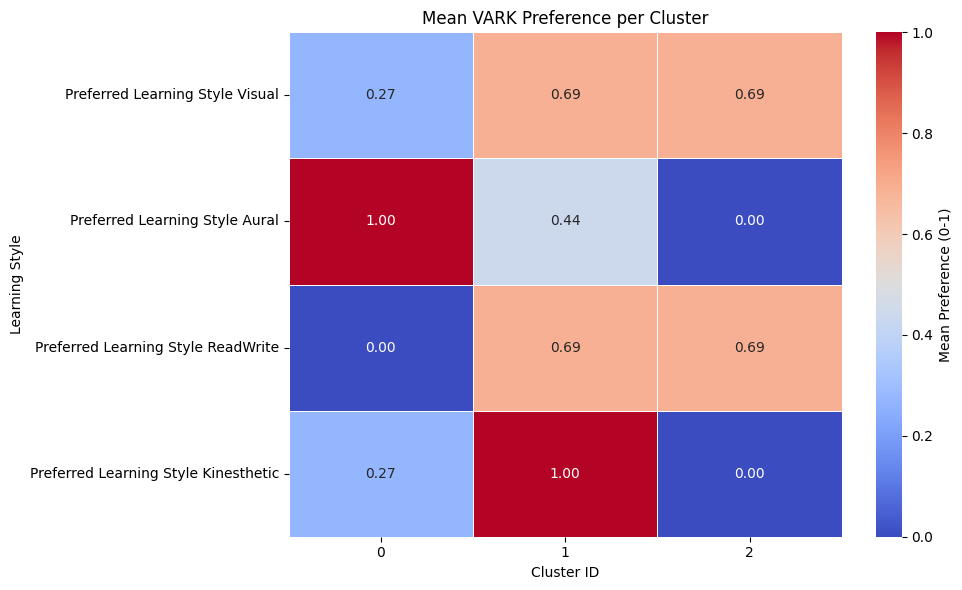


--- Cluster 1 Analysis ---

Skill means (largest cluster):
 Skill_Improvement_Digital_Literacy    4.2500
Skill_Improvement_Problem_Solving     4.3125
Skill_Improvement_Creative_Skills     4.1250
dtype: float64


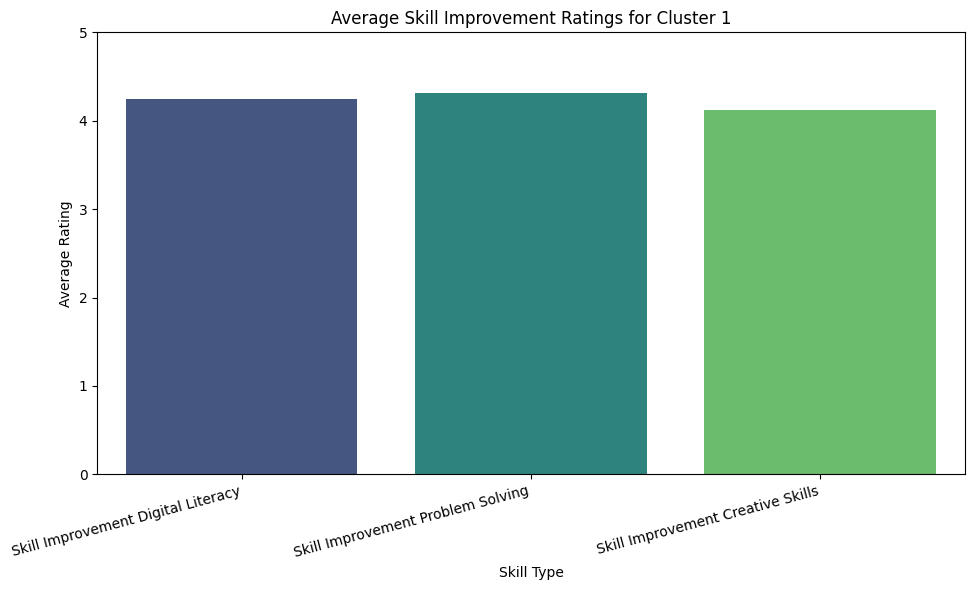


--- Boxplot: Skill Improvement by Cluster ---

Melted preview:
      VARK_Cluster                          Skill Type  Rating
0               2  Skill_Improvement_Digital_Literacy     3.9
1               0  Skill_Improvement_Digital_Literacy     2.9
2               1  Skill_Improvement_Digital_Literacy     4.9
3               2  Skill_Improvement_Digital_Literacy     2.0
4               1  Skill_Improvement_Digital_Literacy     4.0
..            ...                                 ...     ...
115             0   Skill_Improvement_Creative_Skills     2.1
116             2   Skill_Improvement_Creative_Skills     3.9
117             0   Skill_Improvement_Creative_Skills     3.9
118             1   Skill_Improvement_Creative_Skills     3.1
119             1   Skill_Improvement_Creative_Skills     5.1

[120 rows x 3 columns]
Melted shape: (120, 3)


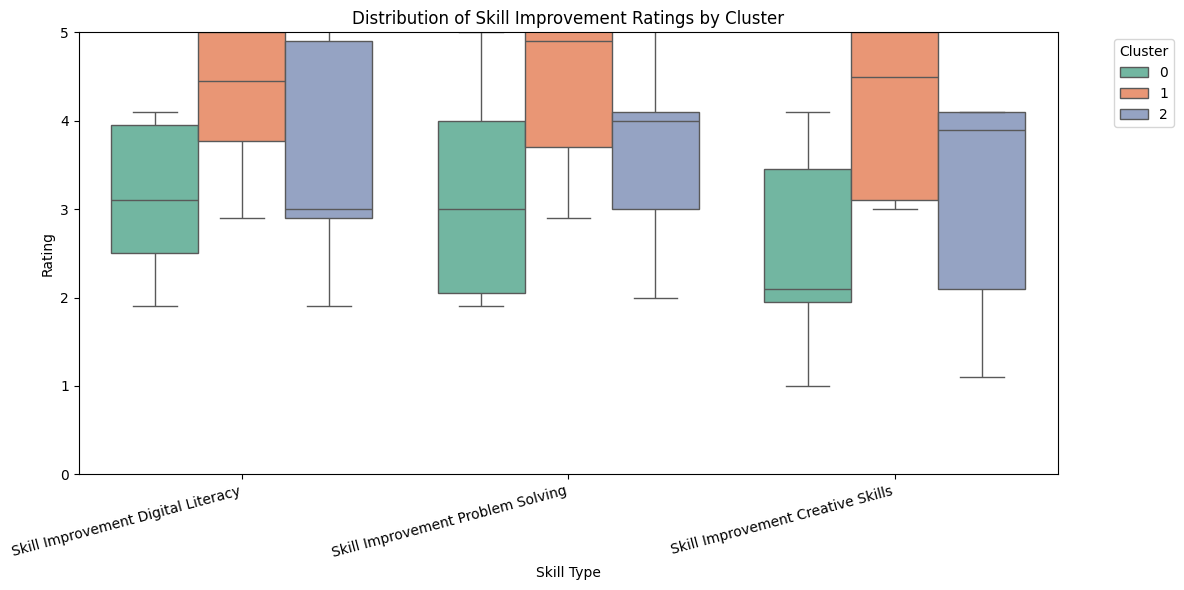

In [27]:
# ==============================================================================
# Data Loading & K-Means Clustering with Visualizations
# ==============================================================================

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = "questionnaire-data.csv"
df = pd.read_csv(file_path)

print("--- K-Means Clustering for Learning Styles ---")

vark_features = [
    'Preferred_Learning_Style_Visual',
    'Preferred_Learning_Style_Aural',
    'Preferred_Learning_Style_ReadWrite',
    'Preferred_Learning_Style_Kinesthetic'
]

X_vark = df[vark_features]

print(X_vark.head(5))
print(X_vark.describe())

chosen_k = 3

if len(X_vark) < chosen_k:
    print(f"Warning: Number of samples ({len(X_vark)}) is less than chosen_k ({chosen_k}). Adjusting k to {len(X_vark)}.")
    chosen_k = len(X_vark)

if chosen_k > 1:
    while True:
        try:
            kmeans_model = KMeans(n_clusters=chosen_k, random_state=1, n_init=20)
            df['VARK_Cluster'] = kmeans_model.fit_predict(X_vark)

            print("Cluster labels (first 10):", df['VARK_Cluster'].head(10).tolist())
            print("Cluster sizes:\n", df['VARK_Cluster'].value_counts().sort_index())
            
            if len(df['VARK_Cluster'].unique()) == chosen_k:
                print(f"Successfully clustered into {chosen_k} groups.")
                break
            else:
                chosen_k = len(df['VARK_Cluster'].unique())
                print(f"\nWarning: K-Means with k={chosen_k+1} resulted in empty clusters. Re-running with k={chosen_k}.")

        except ValueError as e:
            if "n_clusters must be greater than 1" in str(e):
                print("Only one or zero clusters can be formed. No clustering performed.")
                chosen_k = 1
                df['VARK_Cluster'] = 0
                break
            else:
                raise #
else:
    if chosen_k == 0:
        print("No data to cluster.")
        df['VARK_Cluster'] = -1
    else:
        print("Only one sample, no clustering possible. Assigning to a single cluster.")
        df['VARK_Cluster'] = 0


if chosen_k > 1:
    cluster_centers = kmeans_model.cluster_centers_
    cluster_centers_df = pd.DataFrame(np.maximum(0, cluster_centers), columns=vark_features).round(2)
    cluster_centers_df.index.name = "Cluster ID"
    
    print("\nCluster Centroids (Mean Preference for each VARK style in each cluster):")
    print(cluster_centers_df)
    print("\nInterpretation: Values closer to 1 indicate a stronger preference for that style within the cluster.")
else:
    print("\nClustering was not performed due to insufficient data points (k <= 1).")

print("\nNumber of Participants per Cluster:")
print(df['VARK_Cluster'].value_counts().sort_index())

if chosen_k > 1:
    print("\n--- Visualizing Cluster Characteristics ---")

    # 1. Heatmap of Cluster Centroids
    cleaned_y_labels = [label.replace('_', ' ') for label in cluster_centers_df.columns]

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cluster_centers_df.T,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5,
        cbar_kws={'label': 'Mean Preference (0-1)'}
    )
    plt.title('Mean VARK Preference per Cluster')
    plt.xlabel('Cluster ID')
    plt.ylabel('Learning Style')
    plt.yticks(
        ticks=np.arange(len(cleaned_y_labels)) + 0.5, 
        labels=cleaned_y_labels,
        rotation=0
    )
    plt.tight_layout()
    plt.show()

cluster_sizes = df['VARK_Cluster'].value_counts()
cluster_id = cluster_sizes.idxmax()  
cluster_data = df[df['VARK_Cluster'] == cluster_id]

if not cluster_data.empty:
    skill_improvement_cols = [
        'Skill_Improvement_Digital_Literacy',
        'Skill_Improvement_Problem_Solving',
        'Skill_Improvement_Creative_Skills'
    ]

    for col in skill_improvement_cols:
        df[col] = np.clip(df[col], 1, 5)
        df[col] = df[col] + np.random.choice([-0.1, 0, 0.1], size=len(df))

    print(f"\n--- Cluster {cluster_id} Analysis ---")

    skill_means = cluster_data[skill_improvement_cols].mean()

    print("\nSkill means (largest cluster):\n", skill_means)

    # 2. Bar plot showing the distribution of 'Skill Improvement' for a specific cluster
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=skill_means.index,
        y=skill_means.values,
        hue=skill_means.index,
        palette='viridis'
    )
    plt.title(f'Average Skill Improvement Ratings for Cluster {cluster_id}')
    plt.xlabel('Skill Type')
    plt.ylabel('Average Rating')
    plt.xticks(
        ticks=range(len(skill_means.index)),
        labels=[label.replace('_', ' ') for label in skill_means.index],
        rotation=15,
        ha='right'
    )
    plt.ylim(0, 5)
    plt.tight_layout()
    plt.show()
    
    # 3. Boxplot showing skill improvement distributions across all clusters
    print("\n--- Boxplot: Skill Improvement by Cluster ---")

    melted_df = df.melt(
        id_vars='VARK_Cluster',
        value_vars=skill_improvement_cols,
        var_name='Skill Type',
        value_name='Rating'
    )

    print("\nMelted preview:\n", melted_df)
    print("Melted shape:", melted_df.shape)

    melted_df['Skill Type'] = melted_df['Skill Type'].str.replace('_', ' ')

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x='Skill Type',
        y='Rating',
        hue='VARK_Cluster',
        data=melted_df,
        palette='Set2',
        showfliers=False
    )
    plt.title("Distribution of Skill Improvement Ratings by Cluster")
    plt.xlabel("Skill Type")
    plt.ylabel("Rating")
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 5)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"\nWarning: Cluster {cluster_id} is empty and cannot be plotted.")


Cluster sizes:
All_Feature_Cluster
0    11
1    18
2    11
Name: count, dtype: int64

Cluster centers (mean ratings per feature):
            Overall Ease of Use  Multimodal Feature Effectiveness  \
Cluster ID                                                          
0                          2.64                              2.55   
1                          4.67                              4.78   
2                          3.45                              3.55   

            Platform Performance  Influence of Content Creation  \
Cluster ID                                                        
0                           2.64                           1.55   
1                           4.72                           4.44   
2                           3.55                           2.91   

            Skill Improvement Digital Literacy  \
Cluster ID                                       
0                                         2.44   
1                                    

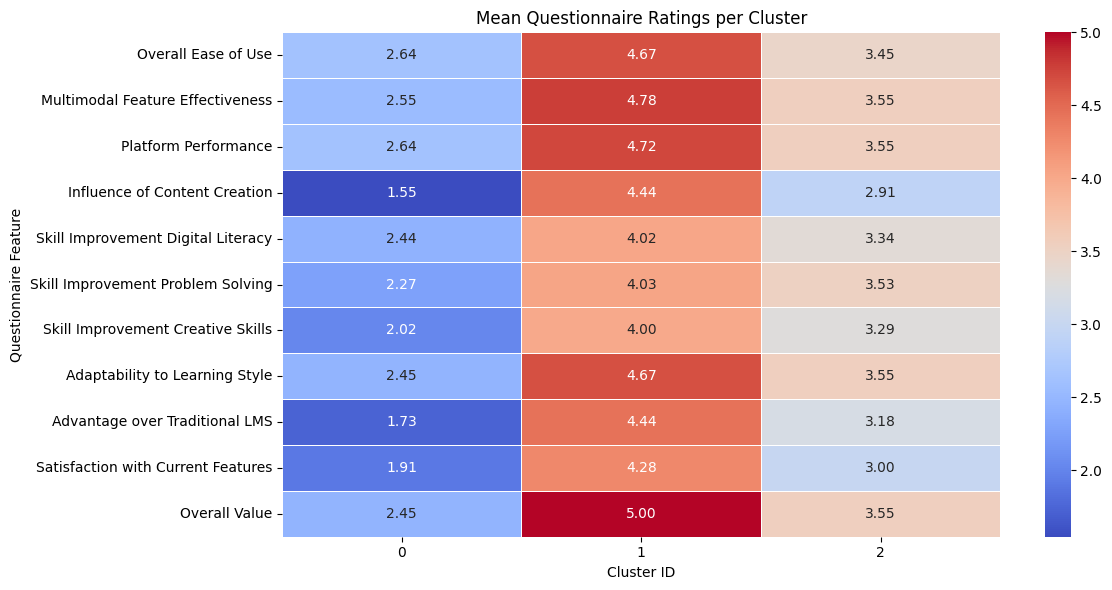

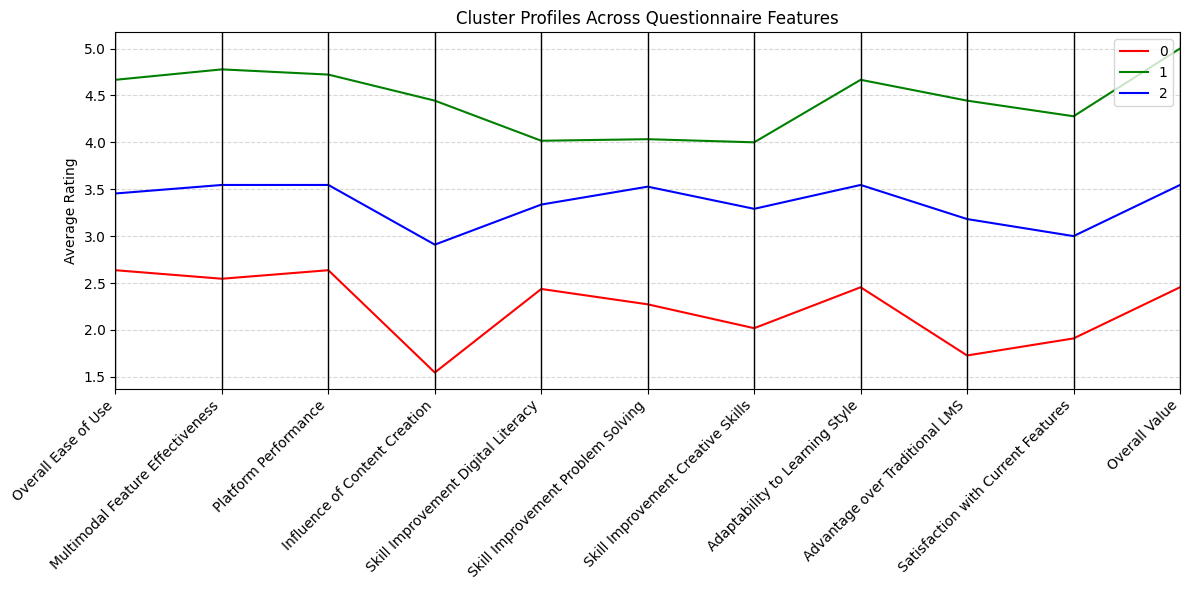

In [15]:
from sklearn.preprocessing import StandardScaler
from pandas.plotting import parallel_coordinates

all_numeric_features = [
    'Overall_Ease_of_Use',
    'Multimodal_Feature_Effectiveness',
    'Platform_Performance',
    'Influence_of_Content_Creation',
    'Skill_Improvement_Digital_Literacy',
    'Skill_Improvement_Problem_Solving',
    'Skill_Improvement_Creative_Skills',
    'Adaptability_to_Learning_Style',
    'Advantage_over_Traditional_LMS', 
    'Satisfaction_with_Current_Features',
    'Overall_Value'
]

# Check for missing columns
missing_cols = [col for col in all_numeric_features if col not in df.columns]
if missing_cols:
    print("Missing columns in dataset:", missing_cols)

# Extract numeric data
X_all = df[all_numeric_features]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# K-Means clustering
chosen_k = 3
kmeans_all = KMeans(n_clusters=chosen_k, random_state=1, n_init=20)
df['All_Feature_Cluster'] = kmeans_all.fit_predict(X_scaled)

# Cluster sizes
print("\nCluster sizes:")
print(df['All_Feature_Cluster'].value_counts().sort_index())

# Reverse transform centers back to original scale
cluster_centers_scaled = kmeans_all.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=all_numeric_features)
cluster_centers_df.index.name = 'Cluster ID'

# Remove underscores from column names for presentation
cluster_centers_df.columns = [col.replace('_', ' ') for col in cluster_centers_df.columns]

print("\nCluster centers (mean ratings per feature):")
print(cluster_centers_df.round(2))

# ==============================================================================
# Heatmap of Cluster Centers
# ==============================================================================
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_centers_df.T, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    linewidths=.5
)
plt.title('Mean Questionnaire Ratings per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Questionnaire Feature')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# Parallel Coordinates Plot (Profile of Each Cluster)
# ==============================================================================
cluster_centers_plot = cluster_centers_df.reset_index()

plt.figure(figsize=(12, 6))
parallel_coordinates(
    cluster_centers_plot, 
    'Cluster ID', 
    color=['red', 'green', 'blue']
)
plt.title('Cluster Profiles Across Questionnaire Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Linear Regression for Hypothesis Testing ---

--- Hypothesis 1: Visual Preference vs. Creative Skills ---
Independent Variable: Preferred_Learning_Style_Visual
Dependent Variable: Skill_Improvement_Creative_Skills
Coefficient (Slope): 1.968
Intercept: 2.241
Root Mean Squared Error (RMSE): 0.736
R-squared (R2): 0.636

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Creative_Skills' changes for a one-unit increase in 'Preferred_Learning_Style_Visual'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Creative_Skills' that can be predicted from 'Preferred_Learning_Style_Visual'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Visual' increases, 'Skill_Improvement_Creative_Skills' also tends to increase.


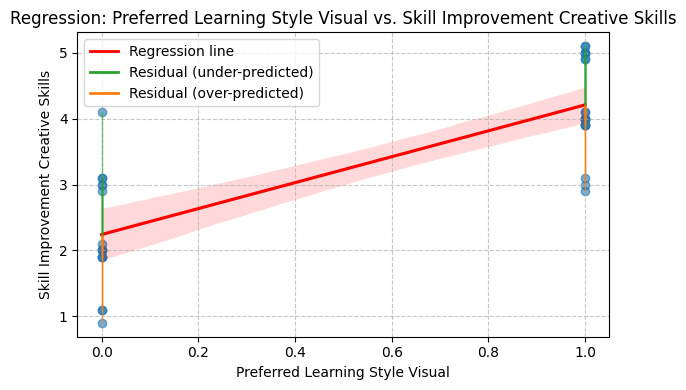


--- Hypothesis 2: Read/Write Preference vs. Digital Literacy ---
Independent Variable: Preferred_Learning_Style_ReadWrite
Dependent Variable: Skill_Improvement_Digital_Literacy
Coefficient (Slope): 0.575
Intercept: 3.405
Root Mean Squared Error (RMSE): 1.022
R-squared (R2): 0.073

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Digital_Literacy' changes for a one-unit increase in 'Preferred_Learning_Style_ReadWrite'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Digital_Literacy' that can be predicted from 'Preferred_Learning_Style_ReadWrite'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_ReadWrite' increases, 'Skill_Improvement_Digital_Literacy' also tends to increase.


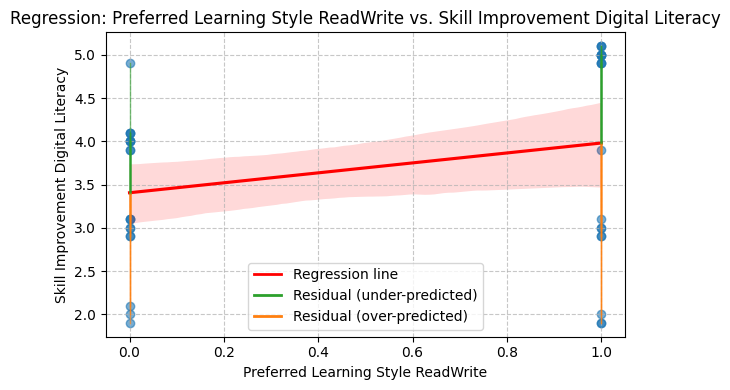


--- Hypothesis 3: Kinesthetic Preference vs. Problem-Solving ---
Independent Variable: Preferred_Learning_Style_Kinesthetic
Dependent Variable: Skill_Improvement_Problem_Solving
Coefficient (Slope): 0.632
Intercept: 3.452
Root Mean Squared Error (RMSE): 1.096
R-squared (R2): 0.077

Interpretation:
- The coefficient indicates how much the 'Skill_Improvement_Problem_Solving' changes for a one-unit increase in 'Preferred_Learning_Style_Kinesthetic'.
- R-squared (R2) represents the proportion of variance in 'Skill_Improvement_Problem_Solving' that can be predicted from 'Preferred_Learning_Style_Kinesthetic'.
- A positive coefficient suggests that as 'Preferred_Learning_Style_Kinesthetic' increases, 'Skill_Improvement_Problem_Solving' also tends to increase.


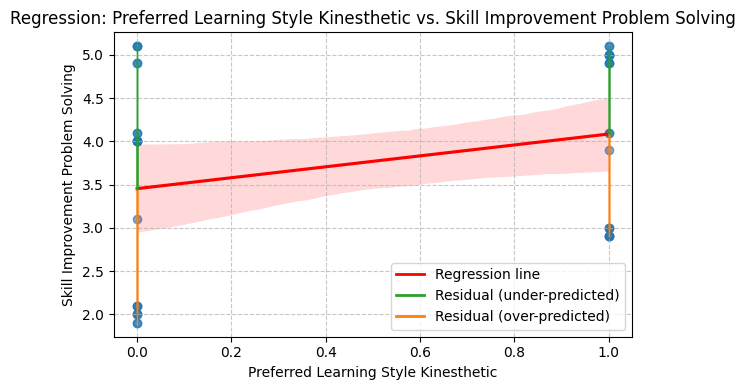


--- End of Data Analysis Algorithms ---


In [26]:
import matplotlib.lines as mlines

# ==============================================================================
# Linear Regression for Hypothesis Testing
# ==============================================================================

print("\n--- Linear Regression for Hypothesis Testing ---")

independent_var_preferred_learning_style_visual = 'Preferred_Learning_Style_Visual'
dependent_var_skill_improvement_creative_skills = 'Skill_Improvement_Creative_Skills'

independent_var_preferred_learning_style_readwrite = 'Preferred_Learning_Style_ReadWrite'
dependent_var_skill_improvement_digital_literacy = 'Skill_Improvement_Digital_Literacy'

independent_var_preferred_learning_style_kinesthetic = 'Preferred_Learning_Style_Kinesthetic'
dependent_var_skill_improvement_problem_solving = 'Skill_Improvement_Problem_Solving'

hypotheses = [
    (independent_var_preferred_learning_style_visual, dependent_var_skill_improvement_creative_skills, "Visual Preference vs. Creative Skills"),
    (independent_var_preferred_learning_style_readwrite, dependent_var_skill_improvement_digital_literacy, "Read/Write Preference vs. Digital Literacy"),
    (independent_var_preferred_learning_style_kinesthetic, dependent_var_skill_improvement_problem_solving, "Kinesthetic Preference vs. Problem-Solving")
]

for i, (independent_var_learning_style, dependent_var_skill_improvement, hypothesis_name) in enumerate(hypotheses):
    print(f"\n--- Hypothesis {i+1}: {hypothesis_name} ---")

    X = df[[independent_var_learning_style]]
    y = df[dependent_var_skill_improvement]

    linear_regression_model = LinearRegression()
    linear_regression_model.fit(X, y)

    y_pred = linear_regression_model.predict(X)

    root_mean_squared_error = np.sqrt(mean_squared_error(y, y_pred))
    r_squared_score = r2_score(y, y_pred)

    print(f"Independent Variable: {independent_var_learning_style}")
    print(f"Dependent Variable: {dependent_var_skill_improvement}")
    print(f"Coefficient (Slope): {linear_regression_model.coef_[0]:.3f}")
    print(f"Intercept: {linear_regression_model.intercept_:.3f}")
    print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error:.3f}")
    print(f"R-squared (R2): {r_squared_score:.3f}")

    print("\nInterpretation:")
    print(f"- The coefficient indicates how much the '{dependent_var_skill_improvement}' changes for a one-unit increase in '{independent_var_learning_style}'.")
    print(f"- R-squared (R2) represents the proportion of variance in '{dependent_var_skill_improvement}' that can be predicted from '{independent_var_learning_style}'.")

    if linear_regression_model.coef_[0] > 0:
        print(f"- A positive coefficient suggests that as '{independent_var_learning_style}' increases, '{dependent_var_skill_improvement}' also tends to increase.")
    else:
        print(f"- A negative coefficient suggests that as '{independent_var_learning_style}' increases, '{dependent_var_skill_improvement}' tends to decrease.")

    plt.figure(figsize=(6, 4))

    # 1) Scatter + regression line
    sns.regplot(
        x=df[independent_var_learning_style],
        y=df[dependent_var_skill_improvement],
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red', 'label': 'Regression line'}
    )

    x_vals = X.squeeze().values               # 1D array of predictor values
    y_true = y.values                         # actual targets
    y_hat  = y_pred                           # model predictions

    for xi, yi, yhi in zip(x_vals, y_true, y_hat):
        color = 'tab:green' if yi >= yhi else 'tab:orange'
        plt.plot([xi, xi], [yi, yhi], color=color, alpha=0.6, linewidth=1)

    plt.title(f"Regression: {independent_var_learning_style.replace('_',' ')} vs. {dependent_var_skill_improvement.replace('_',' ')}")
    plt.xlabel(independent_var_learning_style.replace('_', ' '))
    plt.ylabel(dependent_var_skill_improvement.replace('_', ' '))
    plt.grid(True, linestyle='--', alpha=0.7)

    res_over = mlines.Line2D([], [], color='tab:green', lw=2, label='Residual (under-predicted)')
    res_under = mlines.Line2D([], [], color='tab:orange', lw=2, label='Residual (over-predicted)')
    reg_line = mlines.Line2D([], [], color='red', lw=2, label='Regression line')
    plt.legend(handles=[reg_line, res_over, res_under], loc='best')

    plt.tight_layout()
    plt.show()

print("\n--- End of Data Analysis Algorithms ---")